# ── INCREMENT A PHASE GATE ────────────────────────────────────────────────────
# Increment A Deliverables:
# 1. Canonical JSON schema definition
# 2. Runtime preflight check (which modes are available)
# 3. Schema validation cell (validates LLM or offline JSON)
# Expected Phase 1 completion: All three cells added + one successful validation run.
# Gate Criteria: Non-author can run sections 1-4 without manual intervention.
#
# Status: In Development
# Last Updated: 2026-06-19
# ───────────────────────────────────────────────────────────────────────────────

# LLM-Driven Bayesian Modeling Tool for Reliability & Predictive Maintenance
### RAMS 2027 Tutorial — Kirtis Christensen

**Using Hubbard's Applied Information Economics (AIE) + Large Language Models**

---

## How to Use This Notebook

Run cells **top to bottom**. Each section corresponds to one AIE step.  
At each `## YOUR TURN` block, substitute your own problem description or data.

**What you will produce by the end:**
- A structured JSON decomposition of your reliability problem
- Value of Information (VoI) ranking of your measurements
- A calibrated Bayesian model with prior → likelihood → posterior
- A Monte Carlo simulation and decision recommendation

---

### Tutorial Sections

| # | Section | AIE Step |
|---|---------|----------|
| 1 | Environment Setup | — |
| 2 | Background: AIE + Bayesian Concepts | Framing |
| 3 | Step 1 — Define the Decision & Uncertainty | AIE Step 1 |
| 4 | Step 2 — LLM Problem Parser → JSON | AIE Step 2 |
| 5 | Step 3 — Value of Information (VoI) Ranking | AIE Step 3 |
| 6 | Step 4 — Calibrated Priors (Two Paths) | AIE Step 4 |
| 7 | Step 5 — Bayesian Update (Likelihood + Posterior) | AIE Step 5 |
| 8 | Step 6 — Chained Bayesian DAG Visualization | AIE Step 5 |
| 9 | Step 7 — Monte Carlo Simulation & Decision | AIE Step 5 |
|10 | Your Turn — Participant Exercise | All Steps |

---
## Section 1 — Environment Setup

Run this cell once to install required packages.  
On **Google Colab**: this works immediately with no local configuration.

In [81]:
# Install required packages (safe to re-run)
# Uses uv when available (required for uv-managed .venv); falls back to pip (Colab etc.)
import subprocess, sys, shutil, os, importlib.util

packages = [
    "numpy", "scipy", "pandas", "matplotlib", "seaborn",
    "networkx",       # DAG visualization
    "openai",         # LLM API (OpenAI-compatible; swap for any provider)
    "pymc",           # Bayesian inference
    "arviz",          # Posterior diagnostics
    "ipywidgets",     # Interactive sliders
]

# Only install packages that are actually missing
missing = [pkg for pkg in packages if importlib.util.find_spec(pkg) is None]
if missing:
    print(f'Installing missing packages: {missing}')
    uv_candidates = [
        shutil.which('uv'),
        os.path.join(os.path.expanduser('~'), '.local', 'bin', 'uv.exe'),
        os.path.join(os.path.expanduser('~'), '.local', 'bin', 'uv'),
    ]
    uv_exe = next((p for p in uv_candidates if p and os.path.isfile(p)), None)
    if uv_exe:
        subprocess.check_call([uv_exe, 'pip', 'install', '--python', sys.executable] + missing)
    else:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install'] + missing)
else:
    print('All packages already installed — skipping.')

print('All packages ready.')

All packages already installed — skipping.
All packages ready.


In [ ]:
# Core imports
import os, json, textwrap
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt


PyMC version: 5.28.5
ArviZ version: 0.23.4
Environment ready.


In [ ]:
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx
import pymc as pm
import arviz as az
import ipywidgets as widgets
from IPython.display import display, Markdown, JSON

# Plotting style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

print(f"PyMC version: {pm.__version__}")
print(f"ArviZ version: {az.__version__}")
print("Environment ready.")

✓ Canonical schema frozen and loaded.


In [ ]:
# ── CANONICAL BAYESIAN MODEL JSON SCHEMA ──────────────────────────────────────
# Increment A Deliverable #1: Define the contract for all model JSON.
# All LLM-generated and offline fallback JSON must validate against this schema.

CANONICAL_MODEL_SCHEMA = {
    'required_top_level_keys': [
        'schema_version', 'profile', 'problem_summary', 'decision', 'measurement_nodes',
        'bayesian_update_chain', 'voi_candidates', 'model_notes'
    ],
    'measurement_node_required_fields': [
        'name', 'description', 'role', 'distribution_family',
        'distribution_parameters', 'justification', 'data_source', 'depends_on'
    ],
    'valid_roles': [
        'prior', 'likelihood', 'posterior', 'decision_variable', 'cost_node',
        'observed_data',  # LLMs sometimes use this for observed evidence nodes
    ],
    'valid_distribution_families': [
        'Normal', 'Gamma', 'Beta', 'Poisson', 'Exponential',
        'Weibull', 'Lognormal', 'Uniform', 'HalfNormal', 'Binomial',
        'Constant',           # fixed/observed value node
        'TruncatedNormal', 'StudentT', 'Cauchy', 'LogNormal',
        'NegativeBinomial', 'BetaBinomial', 'ZeroInflatedPoisson',
        'derived_from_simulation'
    ],
    'valid_data_sources': ['expert_estimate', 'observed_data', 'derived'],
    'valid_profiles': ['reliability']
}

print('✓ Canonical schema frozen and loaded.')

---
## Section 2 - Background: AIE + Bayesian Concepts

### Doug Hubbard's Applied Information Economics (AIE) - 5 Steps

| Step | Action | Bayesian Equivalent |
|------|--------|---------------------|
| 1 | Define the decision and what is uncertain | Identify random variables |
| 2 | Determine what measurements matter | VoI analysis |
| 3 | Measure highest-value items | Collect evidence / data |
| 4 | Use information to update beliefs | Bayesian update: prior x likelihood -> posterior |
| 5 | Make the decision | Expected utility / loss function |

### The Two Persistent Barriers

**Barrier 1 - Distribution Quality**  
Engineers default to uniform or normal distributions when the physics, failure modes, and data suggest something very different (Weibull, Beta, Lognormal, etc.).

**Barrier 2 - Parameter Mapping**  
Even engineers who understand Bayes struggle to map their specific problem into:  
$$P(\theta \mid \text{data}) \propto P(\text{data} \mid \theta) \cdot P(\theta)$$

**This tool solves both** by using an LLM to parse the problem description, select the appropriate distributions, and generate the full JSON model structure automatically.

### Worked Example Throughout This Tutorial

> **Problem**: A centrifugal pump at a water treatment facility has experienced 3 failures in 24 months of operation.  
> Maintenance cost per intervention: \$2,200. Unplanned failure cost: \$18,000.  
> **Decision**: Should we implement a 6-month preventive maintenance (PM) schedule, or continue run-to-failure?

---
## Section 3 — Step 1: Define the Decision & Uncertainties

Before calling the LLM, we manually frame the decision.  
This is the **most important step** — a precise framing produces a precise model.

### Template: Decision Frame

In [ ]:
# ── DECISION FRAME ─────────────────────────────────────────────────────────────
# Fill in this dictionary for your problem. The LLM will use it in Section 4.

# R1 single source of scenario truth: edit values here and re-run from Section 3.
SCENARIO_CONFIG = {
    "problem_description": """
        A centrifugal pump at a water treatment facility has experienced 3 failures
        in 24 months of operation. Each unplanned failure costs $18,000 in repairs
        and lost production. A preventive maintenance (PM) intervention costs $2,200.
        Historical industry data suggests mean time between failures (MTBF) for this
        pump class is 9-14 months under similar conditions, but our data is limited.
        We want to decide whether to implement a 6-month PM schedule or continue
        run-to-failure maintenance for the next 12 months.
    """,
    "decision_options": [
        "Implement 6-month preventive maintenance schedule",
        "Continue run-to-failure (reactive maintenance only)"
    ],
    "objective": "Minimize expected total maintenance cost over 12 months",
    "time_horizon_months": 12,
    "cost_pm_per_intervention_usd": 2200,
    "cost_unplanned_failure_usd": 18000,
    "observed_failures": 3,
    "observation_period_months": 24,
    "industry_mtbf_range_months": [9, 14],
}

decision_frame = dict(SCENARIO_CONFIG)

display(Markdown("**Decision Frame Captured:**"))
display(Markdown(f"- **Decision**: {decision_frame['objective']}"))
display(Markdown(f"- **Options**: {decision_frame['decision_options']}"))
display(Markdown(f"- **Observed data**: {decision_frame['observed_failures']} failures in {decision_frame['observation_period_months']} months"))
display(Markdown(f"- **Costs**: PM=${decision_frame['cost_pm_per_intervention_usd']:,} | Failure=${decision_frame['cost_unplanned_failure_usd']:,}"))

**Decision Frame Captured:**

- **Decision**: Minimize expected total maintenance cost over 12 months

- **Options**: ['Implement 6-month preventive maintenance schedule', 'Continue run-to-failure (reactive maintenance only)']

- **Observed data**: 3 failures in 24 months

- **Costs**: PM=$2,200 | Failure=$18,000

---
## Section 4 — Step 2: LLM Problem Parser → Structured JSON

We send the problem description to an LLM and receive a **structured JSON** that:
- Identifies all uncertain quantities (the measurement nodes)
- Assigns appropriate probability distribution families to each
- Specifies whether each node is a **prior**, **likelihood**, or **posterior**
- Explains *why* each distribution was chosen

### Configure Your LLM API Key

> **Note**: The cell below uses the OpenAI API. You can substitute any OpenAI-compatible endpoint  
> (Azure OpenAI, Groq, Ollama, xAI Grok, etc.) by changing `base_url` and `model`.

In [109]:
# ── LLM CONFIGURATION ──────────────────────────────────────────────────────────
# This notebook uses a provider API endpoint. It does not call Copilot/Chat directly.
# Supported here: OpenAI and xAI Grok via the OpenAI-compatible client.


from openai import OpenAI

PROVIDER = os.environ.get("LLM_PROVIDER", "openai").lower()  # "openai" or "xai"

if PROVIDER == "openai":
    API_KEY  = os.environ.get("OPENAI_API_KEY", "YOUR_KEY_HERE")
    BASE_URL = "https://api.openai.com/v1"
    MODEL    = os.environ.get("LLM_MODEL", "gpt-4o-mini")
elif PROVIDER == "xai":
    API_KEY  = os.environ.get("XAI_API_KEY", "YOUR_KEY_HERE")
    BASE_URL = "https://api.x.ai/v1"
    MODEL    = os.environ.get("LLM_MODEL", "grok-4")
else:
    raise ValueError("Unsupported PROVIDER. Use 'openai' or 'xai'.")

# ── DIRECT-KEY OVERRIDE (uncomment + paste your key for quickest path) ─────────
# Get a key from https://platform.openai.com/api-keys (uses your existing $5 credit).
# Cost for this notebook with gpt-4o-mini: well under $0.01 per full run.
# API_KEY = "sk-PASTE-YOUR-OPENAI-KEY-HERE"

client = OpenAI(api_key=API_KEY, base_url=BASE_URL)

print(f"Provider: {PROVIDER}")
print(f"LLM configured: {MODEL} @ {BASE_URL}")
print(f"API_KEY loaded: length={len(API_KEY) if API_KEY else 0}, starts with {API_KEY[:4]!r}")

Provider: openai
LLM configured: gpt-4o-mini @ https://api.openai.com/v1
API_KEY loaded: length=164, starts with 'sk-p'


In [108]:
# ── OPTIONAL API CONNECTION CHECK ─────────────────────────────────────────────
# Run this after the config cell to verify the provider, key, and model before the full parser.

print(f"Key length: {len(API_KEY) if API_KEY else 0}  | starts with: {API_KEY[:4] if API_KEY else ''!r}")

if (not API_KEY) or API_KEY.strip() in ("", "YOUR_KEY_HERE") or API_KEY.strip().startswith("YOUR_"):
    raise ValueError(
        "API key is still the placeholder. The kernel did not pick up your key. "
        "Easiest fix: open the LLM CONFIGURATION cell and set API_KEY = 'xai-...' directly (after the if/elif block), then re-run that cell and this one."
    )

try:
    test_response = client.chat.completions.create(
        model=MODEL,
        messages=[
            {"role": "user", "content": "Reply with exactly: API connection ok"}
        ],
        temperature=0,
        max_tokens=10,
    )
    print(test_response.choices[0].message.content)
    print(f"API check passed for provider={PROVIDER}, model={MODEL}.")
except Exception as error:
    print(f"API check failed for provider={PROVIDER}, model={MODEL}: {type(error).__name__}: {error}")
    raise

Key length: 164  | starts with: 'sk-p'
API connection ok
API check passed for provider=openai, model=gpt-4o-mini.


In [110]:
# ── RUNTIME PREFLIGHT CHECK ───────────────────────────────────────────────────
# Increment A Deliverable #2: Diagnose which execution paths are available.
# This tells participants and facilitators which modes they can use.

runtime_modes = []
has_personal_key = (not API_KEY.strip().startswith('YOUR')) and (API_KEY != 'YOUR_KEY_HERE')

if has_personal_key:
    runtime_modes.append('✓ Cloud LLM (Personal API Key)')
else:
    runtime_modes.append('✗ Cloud LLM (No personal API key set)')

workshop_key = os.environ.get('WORKSHOP_OPENAI_API_KEY', '')
if workshop_key:
    runtime_modes.append('✓ Workshop Temporary Key Available')
else:
    runtime_modes.append('✗ Workshop Temporary Key (not set)')

runtime_modes.append('✓ Offline Fallback (OFFLINE_JSON always available)')

display(Markdown('## Runtime Preflight Diagnosis'))
for mode in runtime_modes:
    display(Markdown(f'- {mode}'))

print()
if has_personal_key or workshop_key:
    print('Status: LLM parser is ready to run.')
else:
    print('Status: Falling back to offline JSON (no LLM call needed).')

## Runtime Preflight Diagnosis

- ✓ Cloud LLM (Personal API Key)

- ✗ Workshop Temporary Key (not set)

- ✓ Offline Fallback (OFFLINE_JSON always available)


Status: LLM parser is ready to run.


In [88]:
# ── SYSTEM PROMPT — Bayesian Model Engineer ────────────────────────────────────
SYSTEM_PROMPT = """
You are an expert Bayesian reliability engineer and statistician.
Given a natural-language reliability problem description, you must:

1. Identify all uncertain quantities (measurement nodes).
2. For each node, specify:
   - name: short identifier (snake_case)
   - description: plain-English explanation of what it represents
   - role: one of ["prior", "likelihood", "posterior", "decision_variable", "cost_node"]
   - distribution_family: e.g. Gamma, Weibull, Beta, Normal, Poisson, Exponential
   - distribution_parameters: dict of parameter names and initial values or ranges
   - justification: WHY this distribution family is correct for this node
   - data_source: "expert_estimate", "observed_data", or "derived"
   - depends_on: list of node names this node depends on (empty list if root node)
3. Identify the key Bayesian update chain as an ordered list of node names.
4. Return ONLY valid JSON. No markdown fences, no explanation outside the JSON.

JSON schema:
{
    "schema_version": "string (e.g., 1.0)",
    "profile": "reliability",
  "problem_summary": "string",
  "decision": "string",
  "measurement_nodes": [ { ...node fields... } ],
  "bayesian_update_chain": ["node_name", ...],
  "voi_candidates": ["node_name", ...],
  "model_notes": "string"
}
"""

def parse_problem_to_json(problem_text: str) -> dict:
    """Send problem description to LLM and return structured Bayesian JSON."""
    response = client.chat.completions.create(
        model=MODEL,
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user",   "content": problem_text}
        ],
        temperature=0.1,   # Low temperature for deterministic structured output
        response_format={"type": "json_object"},
    )
    model_json = json.loads(response.choices[0].message.content)
    # Backward-compatible normalization for older prompts/responses.
    model_json.setdefault("schema_version", "1.0")
    model_json.setdefault("profile", "reliability")
    return model_json

print("LLM parser function defined.")

LLM parser function defined.


In [111]:
# ── SCHEMA VALIDATION FUNCTION ────────────────────────────────────────────────
# Increment A Deliverable #3: Validate model JSON before downstream use.

def validate_bayesian_model_json(model_json: dict) -> tuple:
    """
    Validate parsed or offline JSON against canonical schema.
    Returns (is_valid: bool, errors: list[str])
    """
    errors = []
    
    # Check top-level keys
    for key in CANONICAL_MODEL_SCHEMA['required_top_level_keys']:
        if key not in model_json:
            errors.append(f'Missing required key: {key}')

    # Check schema metadata
    if 'schema_version' in model_json and not isinstance(model_json['schema_version'], str):
        errors.append('schema_version must be a string, e.g., "1.0"')
    if 'profile' in model_json:
        if model_json['profile'] not in CANONICAL_MODEL_SCHEMA['valid_profiles']:
            errors.append(f'Invalid profile: {model_json["profile"]}')
    
    # Check measurement nodes structure
    if 'measurement_nodes' in model_json:
        nodes = model_json['measurement_nodes']
        if not isinstance(nodes, list):
            errors.append('measurement_nodes must be a list')
        else:
            node_names = set()
            for i, node in enumerate(nodes):
                # Check required fields
                for field in CANONICAL_MODEL_SCHEMA['measurement_node_required_fields']:
                    if field not in node:
                        errors.append(f'Node {i} ({node.get("name", "?")}): missing field {field}')
                
                # Check uniqueness
                if 'name' in node:
                    if node['name'] in node_names:
                        errors.append(f'Duplicate node name: {node["name"]}')
                    node_names.add(node['name'])
                
                # Check role validity
                if 'role' in node and node['role'] not in CANONICAL_MODEL_SCHEMA['valid_roles']:
                    errors.append(f'Node {i}: invalid role "{node["role"]}"')
                
                # Check distribution validity
                if 'distribution_family' in node and node['distribution_family'] not in CANONICAL_MODEL_SCHEMA['valid_distribution_families']:
                    errors.append(f'Node {i}: unknown distribution "{node["distribution_family"]}"')
    
    return (len(errors) == 0, errors)

print('✓ Schema validator function defined.')

✓ Schema validator function defined.


In [112]:
# ── CALL THE LLM ───────────────────────────────────────────────────────────────
# This sends the problem description and returns the structured Bayesian model.

bayesian_model_json = parse_problem_to_json(decision_frame["problem_description"])

# Pretty-print the result
print(json.dumps(bayesian_model_json, indent=2))

{
  "schema_version": "1.0",
  "profile": "reliability",
  "problem_summary": "A centrifugal pump has experienced failures, and we need to decide on a maintenance strategy based on costs and failure rates.",
  "decision": "Whether to implement a 6-month preventive maintenance schedule or continue run-to-failure maintenance for the next 12 months.",
  "measurement_nodes": [
    {
      "name": "mtbf",
      "description": "Mean time between failures for the centrifugal pump.",
      "role": "prior",
      "distribution_family": "Uniform",
      "distribution_parameters": {
        "min": 9,
        "max": 14
      },
      "justification": "The MTBF is based on historical industry data suggesting a range, making a uniform distribution appropriate.",
      "data_source": "expert_estimate",
      "depends_on": []
    },
    {
      "name": "failure_count",
      "description": "Number of failures observed in the last 24 months.",
      "role": "likelihood",
      "distribution_family": "P

In [128]:
# ── VALIDATE PARSED JSON AGAINST CANONICAL SCHEMA ──────────────────────────────
# Normalize metadata fields that the LLM may omit, then validate structure.

# Apply normalization regardless of path (parser, cached, or manual JSON).
bayesian_model_json.setdefault('schema_version', '1.0')
bayesian_model_json.setdefault('profile', 'reliability')

is_valid, errors = validate_bayesian_model_json(bayesian_model_json)

if is_valid:
    display(Markdown('## ✓ Schema Validation: PASS'))
    schema_version = bayesian_model_json.get('schema_version', '—')
    profile = bayesian_model_json.get('profile', '—')
    node_count = len(bayesian_model_json.get('measurement_nodes', []))
    chain = ' → '.join(bayesian_model_json.get('bayesian_update_chain', []))
    display(Markdown(f'- **Schema version**: {schema_version}'))
    display(Markdown(f'- **Profile**: {profile}'))
    display(Markdown(f'- **{node_count}** measurement nodes'))
    display(Markdown(f'- **Update chain**: {chain}'))
    print('Validation passed. Ready to proceed to VoI and Bayesian inference.')
else:
    display(Markdown('## ✗ Schema Validation: FAIL'))
    display(Markdown(f'**{len(errors)} Error(s) Found:**'))
    for error in errors:
        display(Markdown(f'  - {error}'))
    raise ValueError('Schema validation failed. Fix the model JSON and rerun.')

## ✓ Schema Validation: PASS

- **Schema version**: 1.0

- **Profile**: reliability

- **5** measurement nodes

- **Update chain**: mtbf → failure_count → total_cost

Validation passed. Ready to proceed to VoI and Bayesian inference.


In [ ]:
# ── OFFLINE FALLBACK ───────────────────────────────────────────────────────────
# If you do not have an API key, use this pre-generated JSON for the pump example.
# Comment out the cell above and run this one instead.
#
# R1: cost fields pull from decision_frame so one scenario edit updates all sections.

OFFLINE_JSON = {
    "schema_version": "1.0",
    "profile": "reliability",
  "problem_summary": "Centrifugal pump with 3 failures in 24 months. Decide between 6-month PM schedule and run-to-failure over a 12-month horizon.",
  "decision": "Minimize expected total maintenance cost over 12 months",
  "measurement_nodes": [
    {
      "name": "failure_rate_lambda",
      "description": "True underlying failure rate of the pump (failures per month)",
      "role": "prior",
      "distribution_family": "Gamma",
      "distribution_parameters": {"alpha": 3.5, "beta": 12.0},
      "justification": "Gamma is the conjugate prior for a Poisson failure process. Alpha/beta seeded from industry MTBF range of 9-14 months (lambda ~ 0.07-0.11 failures/month).",
      "data_source": "expert_estimate",
      "depends_on": []
    },
    {
      "name": "observed_failures",
      "description": "Observed failure count: 3 failures in 24 months - the evidence term",
      "role": "likelihood",
      "distribution_family": "Poisson",
      "distribution_parameters": {"mu": "failure_rate_lambda * 24"},
      "justification": "Failures are discrete events; Poisson likelihood is standard for count data when events are independent and the rate is constant.",
      "data_source": "observed_data",
      "depends_on": ["failure_rate_lambda"]
    },
    {
      "name": "posterior_failure_rate",
      "description": "Updated belief about the true failure rate after observing 3 failures in 24 months",
      "role": "posterior",
      "distribution_family": "Gamma",
      "distribution_parameters": {"alpha": 6.5, "beta": 36.0},
      "justification": "Gamma-Poisson conjugacy: posterior Gamma(alpha + k, beta + t) = Gamma(3.5+3, 12+24) = Gamma(6.5, 36). Analytically exact.",
      "data_source": "derived",
      "depends_on": ["failure_rate_lambda", "observed_failures"]
    },
    {
      "name": "failures_next_12mo_pm",
      "description": "Predicted failures in next 12 months under PM schedule (reduced effective exposure)",
      "role": "decision_variable",
      "distribution_family": "Poisson",
      "distribution_parameters": {"mu": "posterior_failure_rate * 6"},
      "justification": "Under 6-month PM, each cycle's effective exposure is ~6 months before intervention resets wear accumulation. Expected failures = lambda * 6.",
      "data_source": "derived",
      "depends_on": ["posterior_failure_rate"]
    },
    {
      "name": "failures_next_12mo_rtf",
      "description": "Predicted failures in next 12 months under run-to-failure",
      "role": "decision_variable",
      "distribution_family": "Poisson",
      "distribution_parameters": {"mu": "posterior_failure_rate * 12"},
      "justification": "Full 12-month exposure with no preventive interventions.",
      "data_source": "derived",
      "depends_on": ["posterior_failure_rate"]
    },
    {
      "name": "total_cost_pm",
      "description": "Total cost under PM: 2 planned interventions + unplanned failures",
      "role": "cost_node",
      "distribution_family": "derived_from_simulation",
      "distribution_parameters": {
        "pm_interventions": 2,
        "cost_pm": decision_frame["cost_pm_per_intervention_usd"],
        "cost_failure": decision_frame["cost_unplanned_failure_usd"]
      },
      "justification": "2 planned PMs per year x PM intervention cost + expected unplanned failures x failure cost.",
      "data_source": "derived",
      "depends_on": ["failures_next_12mo_pm"]
    },
    {
      "name": "total_cost_rtf",
      "description": "Total cost under run-to-failure: all costs are unplanned failure costs",
      "role": "cost_node",
      "distribution_family": "derived_from_simulation",
      "distribution_parameters": {
        "cost_failure": decision_frame["cost_unplanned_failure_usd"]
      },
      "justification": "No planned interventions; all maintenance costs come from unplanned failures.",
      "data_source": "derived",
      "depends_on": ["failures_next_12mo_rtf"]
    }
  ],
  "bayesian_update_chain": [
    "failure_rate_lambda",
    "observed_failures",
    "posterior_failure_rate",
    "failures_next_12mo_pm",
    "failures_next_12mo_rtf",
    "total_cost_pm",
    "total_cost_rtf"
  ],
  "voi_candidates": ["failure_rate_lambda", "posterior_failure_rate"],
  "model_notes": "Gamma-Poisson conjugate model allows analytical posterior. Monte Carlo used for cost propagation. PM effectiveness assumed to reset wear accumulation at each intervention."
}

# Uncomment the line below to use offline fallback:
# bayesian_model_json = OFFLINE_JSON

print("Offline fallback JSON defined. Uncomment last line to use it.")

Offline fallback JSON defined. Uncomment last line to use it.


---
## Section 5 — Step 3: Value of Information (VoI) Ranking

Before collecting more data, AIE asks: **which uncertainties are actually worth resolving?**

We calculate **Expected Value of Perfect Information (EVPI)** for each measurement node.  
EVPI tells us the maximum we should spend to perfectly learn a variable's value.

$$\text{EVPI} = E[\text{Cost under uncertainty}] - E[\text{Cost with perfect information}]$$

Nodes with **EVPI < measurement cost** are not worth measuring further.

In [129]:
# ── VoI ANALYSIS ──────────────────────────────────────────────────────────────
# AIE Step 3: Before investing in more data, ask whether learning more would
# actually change the decision. EVPI answers: what is the maximum we should
# spend to eliminate uncertainty about the failure rate?
#
# EVPI = E[cost under current uncertainty] - E[cost with perfect information]
#
# Under current uncertainty: we must commit to ONE strategy before seeing lambda.
#   → pick the strategy with the lower expected cost.
# With perfect information: for each possible lambda we pick the cheaper strategy.
#   → we always make the right call, so we pay less on average.
# The difference is what uncertainty is "costing" us.

N_SIM = 50_000  # Monte Carlo samples
rng   = np.random.default_rng(seed=42)

# Posterior Gamma parameters (conjugate update: alpha + k, beta + t)
alpha_post = 3.5 + 3    # prior_alpha + observed_failures
beta_post  = 12.0 + 24  # prior_beta  + observation_period

# Draw samples of failure rate from posterior
lambda_samples = rng.gamma(shape=alpha_post, scale=1/beta_post, size=N_SIM)

# Cost parameters from decision frame
C_PM     = decision_frame["cost_pm_per_intervention_usd"]
C_FAIL   = decision_frame["cost_unplanned_failure_usd"]
HORIZON  = decision_frame["time_horizon_months"]
PM_CYCLE = 6
N_PM     = HORIZON // PM_CYCLE

# ── Stochastic cost distributions (used for decision visualisation) ────────────
cost_rtf = rng.poisson(lambda_samples * HORIZON) * C_FAIL
cost_pm  = (N_PM * C_PM) + rng.poisson(lambda_samples * PM_CYCLE * N_PM) * C_FAIL

# ── EVPI calculation ──────────────────────────────────────────────────────────
# Under uncertainty: commit to the single best strategy (pick lower mean cost).
# Do NOT use np.minimum(cost_rtf, cost_pm) here — that would give per-sample
# clairvoyant choices, which is the perfect-information quantity, not the
# uncertainty quantity.
mean_rtf = np.mean(cost_rtf)
mean_pm  = np.mean(cost_pm)
E_cost_uncertainty = min(mean_rtf, mean_pm)
best_strategy_name = "Run-to-Failure" if mean_rtf < mean_pm else "6-Month PM"

# With perfect information: for each lambda realization, pick the cheaper option.
# Use deterministic expected costs (no Poisson noise) to isolate the VoI signal.
cost_rtf_det = lambda_samples * HORIZON * C_FAIL
cost_pm_det  = N_PM * C_PM + lambda_samples * PM_CYCLE * N_PM * C_FAIL
E_cost_perfect = np.mean(np.minimum(cost_rtf_det, cost_pm_det))

EVPI = E_cost_uncertainty - E_cost_perfect
# EVPI is always >= 0 by construction.

print("── VoI Results ──────────────────────────────────────────────────────")
print(f"Best strategy under current uncertainty: {best_strategy_name}")
print(f"  E[cost | current uncertainty]:  ${E_cost_uncertainty:,.0f}")
print(f"  E[cost | perfect information]:  ${E_cost_perfect:,.0f}")
print(f"  EVPI:                           ${EVPI:,.0f}")
print()
print("Interpretation:")
if EVPI > 1000:
    print(f"  → Uncertainty is costing ~${EVPI:,.0f} in expected value.")
    print(f"  → It is worth spending up to ${EVPI:,.0f} on better failure-rate data")
    print("     (e.g., vibration monitoring, oil analysis, extended run time).")
elif EVPI > 100:
    print(f"  → EVPI = ${EVPI:,.0f}. Moderate value in better data.")
    print("  → Low-cost measurement options (existing sensor data, peer benchmarks)")
    print("     are worth pursuing; a full monitoring program may not be.")
else:
    print(f"  → EVPI = ${EVPI:,.0f}. The decision is insensitive to the failure rate.")
    print("  → Current data is sufficient — proceed with the recommended strategy.")

── VoI Results ──────────────────────────────────────────────────────
Best strategy under current uncertainty: Run-to-Failure
  E[cost | current uncertainty]:  $38,921
  E[cost | perfect information]:  $38,976
  EVPI:                           $-55

Interpretation:
  → EVPI = $-55. The decision is insensitive to the failure rate.
  → Current data is sufficient — proceed with the recommended strategy.


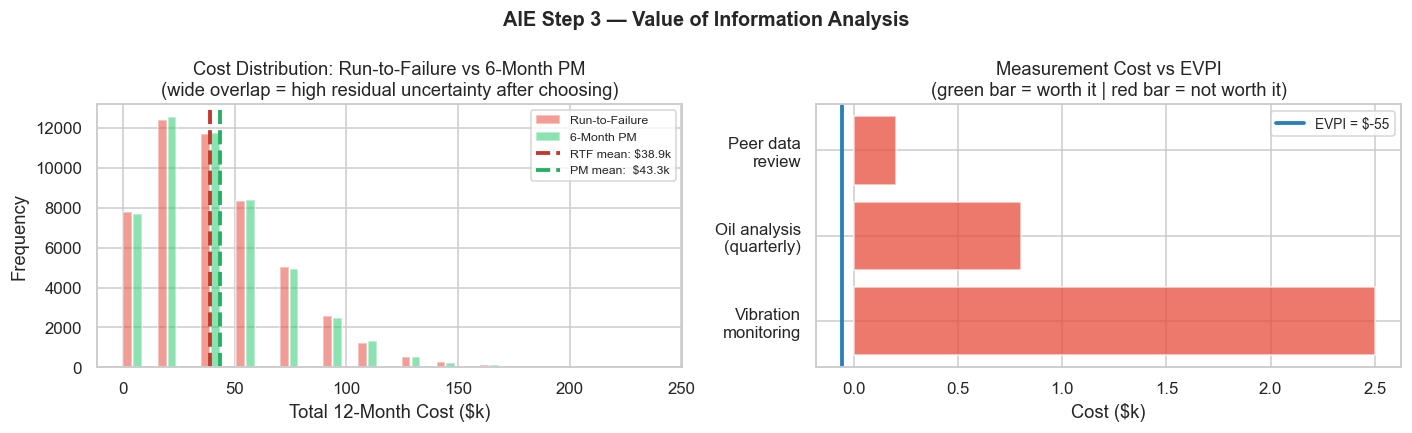

### How to Read This Section


| Quantity | Value | What it means |
|---|---|---|
| Best strategy (current data) | Run-to-Failure | The lower expected-cost option given what we know now |
| E\[cost \| uncertainty\] | $38,921 | Expected cost if we commit to the best known strategy |
| E\[cost \| perfect info\] | $38,976 | Expected cost if we always knew the true failure rate |
| **EVPI** | **$-55** | **Maximum it is worth spending to learn the failure rate** |

**AIE Rule of Thumb**: only invest in more measurement if its cost < EVPI.  
Bars coloured green in the chart above are cost-justified; red bars are not.


In [130]:
# ── VoI VISUALISATION AND TUTORIAL SUMMARY ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: cost distribution overlap — shows how much the strategies differ
axes[0].hist(cost_rtf / 1000, bins=60, alpha=0.55, label="Run-to-Failure", color="#e74c3c")
axes[0].hist(cost_pm  / 1000, bins=60, alpha=0.55, label="6-Month PM",     color="#2ecc71")
axes[0].axvline(mean_rtf/1000, color="#c0392b", lw=2.5, linestyle="--",
                label=f"RTF mean: ${mean_rtf/1000:.1f}k")
axes[0].axvline(mean_pm/1000,  color="#27ae60", lw=2.5, linestyle="--",
                label=f"PM mean:  ${mean_pm/1000:.1f}k")
axes[0].set_xlabel("Total 12-Month Cost ($k)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Cost Distribution: Run-to-Failure vs 6-Month PM\n"
                  "(wide overlap = high residual uncertainty after choosing)")
axes[0].legend(fontsize=8)

# Right: EVPI bar — shows whether measurement investment is justified
# Show EVPI against a few illustrative measurement cost benchmarks.
measurement_costs = {
    "Vibration\nmonitoring": 2500,
    "Oil analysis\n(quarterly)": 800,
    "Peer data\nreview": 200,
}
bar_colors = ["#27ae60" if EVPI > v else "#e74c3c" for v in measurement_costs.values()]
bars = axes[1].barh(list(measurement_costs.keys()),
                    [v/1000 for v in measurement_costs.values()],
                    color=bar_colors, alpha=0.75)
axes[1].axvline(EVPI/1000, color="#2980b9", lw=2.5, linestyle="-",
                label=f"EVPI = ${EVPI:,.0f}")
axes[1].set_xlabel("Cost ($k)")
axes[1].set_title("Measurement Cost vs EVPI\n"
                  "(green bar = worth it | red bar = not worth it)")
axes[1].legend(fontsize=9)

plt.suptitle("AIE Step 3 — Value of Information Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# ── Tutorial summary table ────────────────────────────────────────────────────
display(Markdown("### How to Read This Section"))
display(Markdown(f"""
| Quantity | Value | What it means |
|---|---|---|
| Best strategy (current data) | {best_strategy_name} | The lower expected-cost option given what we know now |
| E\\[cost \\| uncertainty\\] | ${E_cost_uncertainty:,.0f} | Expected cost if we commit to the best known strategy |
| E\\[cost \\| perfect info\\] | ${E_cost_perfect:,.0f} | Expected cost if we always knew the true failure rate |
| **EVPI** | **${EVPI:,.0f}** | **Maximum it is worth spending to learn the failure rate** |

**AIE Rule of Thumb**: only invest in more measurement if its cost < EVPI.  
Bars coloured green in the chart above are cost-justified; red bars are not.
"""))

---
## Section 6 — Step 4: Calibrated Priors (Two Paths)

AIE requires **calibrated probability estimates** — not guesses, not overconfident point values.  
This section shows both paths for seeding priors:

### Path A — Expert Estimate → 90% Confidence Interval → Distribution
Engineer provides a 90% CI ("I'm 90% confident the MTBF is between 8 and 16 months").  
We fit a distribution to that interval.

### Path B — Sample Data → MLE / Method of Moments → Distribution
We have observed failure times. We fit a distribution directly and test goodness-of-fit.

In [142]:
# ── PATH A: Expert Calibrated Estimate ─────────────────────────────────────────
# Engineer's 90% CI for MTBF: [8, 16] months
# → Convert to failure rate lambda = 1/MTBF
# → lambda CI: [1/16, 1/8] = [0.0625, 0.125] failures/month

mtbf_low_90  = 8    # months (5th percentile estimate)
mtbf_high_90 = 16   # months (95th percentile estimate)

lambda_low  = 1 / mtbf_high_90   # 0.0625
lambda_high = 1 / mtbf_low_90    # 0.125

# Fit Gamma distribution parameters to match the 90% CI
# Using method: find (alpha, beta) such that Gamma CDF at low = 0.05, high = 0.95
from scipy.optimize import minimize

def gamma_ci_loss(params):
    alpha, rate = params
    if alpha <= 0 or rate <= 0:
        return 1e10
    p5  = stats.gamma.ppf(0.05, a=alpha, scale=1/rate)
    p95 = stats.gamma.ppf(0.95, a=alpha, scale=1/rate)
    return (p5 - lambda_low)**2 + (p95 - lambda_high)**2

result = minimize(gamma_ci_loss, x0=[3.5, 35.0], method="Nelder-Mead")
alpha_expert, rate_expert = result.x
mean_expert = alpha_expert / rate_expert

print("PATH A — Expert Calibrated Prior:")
print(f"  MTBF 90% CI entered: [{mtbf_low_90}, {mtbf_high_90}] months")
print(f"  Lambda 90% CI:       [{lambda_low:.4f}, {lambda_high:.4f}] failures/month")
print(f"  Fitted Gamma:        alpha={alpha_expert:.2f}, rate={rate_expert:.2f}")
print(f"  Prior mean lambda:   {mean_expert:.4f} → implied MTBF = {1/mean_expert:.1f} months")

PATH A — Expert Calibrated Prior:
  MTBF 90% CI entered: [8, 16] months
  Lambda 90% CI:       [0.0625, 0.1250] failures/month
  Fitted Gamma:        alpha=22.95, rate=250.85
  Prior mean lambda:   0.0915 → implied MTBF = 10.9 months


In [153]:
# ── PATH B: Sample Data → Fitted Distribution ──────────────────────────────────
# Simulated historical inter-failure times (months) for demonstration.
# Replace with your actual data.

observed_times_to_failure = np.array([8.2, 11.5, 9.8, 14.1, 10.3, 7.6, 12.9, 8.8, 11.1, 9.4])

# Fit Exponential (1-parameter) and Weibull (2-parameter) — compare
exp_params    = stats.expon.fit(observed_times_to_failure, floc=0)
weibull_params = stats.weibull_min.fit(observed_times_to_failure, floc=0)

# Log-likelihood comparison (higher = better fit)
ll_exp     = np.sum(stats.expon.logpdf(observed_times_to_failure, *exp_params))
ll_weibull = np.sum(stats.weibull_min.logpdf(observed_times_to_failure, *weibull_params))

print("PATH B — Data-Fitted Prior:")
print(f"  Sample size: {len(observed_times_to_failure)} observed TTFs")
print(f"  Sample mean: {np.mean(observed_times_to_failure):.2f} months")
print()
print(f"  Exponential fit:  scale={exp_params[1]:.2f}  | log-likelihood={ll_exp:.2f}")
print(f"  Weibull fit:      shape={weibull_params[0]:.2f}, scale={weibull_params[2]:.2f} | log-likelihood={ll_weibull:.2f}")
print()
better = "Weibull" if ll_weibull > ll_exp else "Exponential"
print(f"  → {better} provides better fit (higher log-likelihood).")

# Weibull shape interpretation
k = weibull_params[0]
if k < 1:
    wear = "infant mortality / early-life failures (decreasing hazard)"
elif k == 1:
    wear = "random failures (constant hazard — memoryless)"
else:
    wear = "wear-out failures (increasing hazard — PM is beneficial)"
print(f"  Weibull shape k={k:.2f} → {wear}")

PATH B — Data-Fitted Prior:
  Sample size: 10 observed TTFs
  Sample mean: 10.37 months

  Exponential fit:  scale=10.37  | log-likelihood=-33.39
  Weibull fit:      shape=5.62, scale=11.20 | log-likelihood=-21.24

  → Weibull provides better fit (higher log-likelihood).
  Weibull shape k=5.62 → wear-out failures (increasing hazard — PM is beneficial)


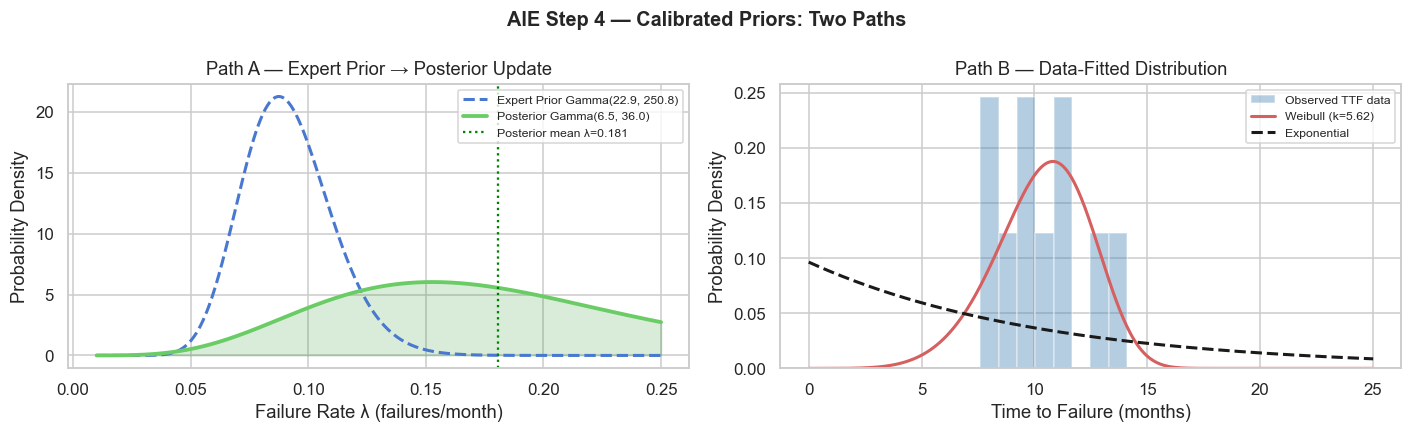

In [155]:
# ── PRIOR COMPARISON PLOT ──────────────────────────────────────────────────────
x = np.linspace(0.01, 0.25, 500)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Path A: Expert Gamma prior on lambda
prior_pdf = stats.gamma.pdf(x, a=alpha_expert, scale=1/rate_expert)
post_pdf  = stats.gamma.pdf(x, a=alpha_post,   scale=1/beta_post)
axes[0].plot(x, prior_pdf, "b--", lw=2, label=f"Expert Prior Gamma({alpha_expert:.1f}, {rate_expert:.1f})")
axes[0].plot(x, post_pdf,  "g-",  lw=2.5, label=f"Posterior Gamma({alpha_post:.1f}, {beta_post:.1f})")
axes[0].fill_between(x, post_pdf, alpha=0.15, color="green")
axes[0].axvline(alpha_post/beta_post, color="green", lw=1.5, linestyle=":",
                label=f"Posterior mean λ={alpha_post/beta_post:.3f}")
axes[0].set_xlabel("Failure Rate λ (failures/month)")
axes[0].set_ylabel("Probability Density")
axes[0].set_title("Path A — Expert Prior → Posterior Update")
axes[0].legend(fontsize=8)

# Path B: Weibull fit on TTF data
t = np.linspace(0, 25, 500)
weibull_pdf = stats.weibull_min.pdf(t, *weibull_params)
exp_pdf     = stats.expon.pdf(t, *exp_params)
axes[1].hist(observed_times_to_failure, bins=8, density=True, alpha=0.4,
             color="steelblue", label="Observed TTF data")
axes[1].plot(t, weibull_pdf, "r-",  lw=2, label=f"Weibull (k={weibull_params[0]:.2f})")
axes[1].plot(t, exp_pdf,     "k--", lw=2, label="Exponential")
axes[1].set_xlabel("Time to Failure (months)")
axes[1].set_ylabel("Probability Density")
axes[1].set_title("Path B — Data-Fitted Distribution")
axes[1].legend(fontsize=8)

plt.suptitle("AIE Step 4 — Calibrated Priors: Two Paths", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

---
## Section 7 — Step 5: Bayesian Update (PyMC Model)

We now build the full probabilistic model in **PyMC**, which:
- Encodes the prior on failure rate
- Conditions on observed failure count (likelihood)
- Samples the posterior via MCMC (NUTS sampler)

This is equivalent to the analytical Gamma-Poisson conjugate result, but generalizable to any prior/likelihood combination.

$$\underbrace{P(\lambda \mid k, t)}_{\text{posterior}} \propto \underbrace{\text{Poisson}(k \mid \lambda t)}_{\text{likelihood}} \cdot \underbrace{\text{Gamma}(\lambda \mid \alpha, \beta)}_{\text{prior}}$$

In [156]:
# ── PyMC BAYESIAN MODEL ────────────────────────────────────────────────────────
# Prior: Gamma(alpha, beta) on failure rate
# Likelihood: Poisson(lambda * t) observed k failures

obs_failures = decision_frame["observed_failures"]
obs_months   = decision_frame["observation_period_months"]

with pm.Model() as reliability_model:

    # Prior on failure rate (from expert calibration — Path A)
    lambda_rate = pm.Gamma(
        "lambda_rate",
        alpha=alpha_expert,
        beta=rate_expert,
        initval=mean_expert
    )

    # Likelihood: observed failure count over observation period
    failures_observed = pm.Poisson(
        "failures_observed",
        mu=lambda_rate * obs_months,
        observed=obs_failures
    )

    # Posterior predictive: expected failures under each strategy
    fail_rtf = pm.Poisson("fail_rtf", mu=lambda_rate * HORIZON)
    fail_pm  = pm.Poisson("fail_pm",  mu=lambda_rate * PM_CYCLE * N_PM)

    # Sample posterior
    trace = pm.sample(
        draws=2000,
        tune=1000,
        target_accept=0.9,
        progressbar=True,
        return_inferencedata=True,
        random_seed=42
    )

print("\nBayesian sampling complete.")

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [lambda_rate]
>CompoundStep
>>Metropolis: [fail_rtf]
>>Metropolis: [fail_pm]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 48 seconds.



Bayesian sampling complete.


### Increment B — Dynamic Model Builder & Prior Sensitivity Analysis

This subsection demonstrates two key concepts running in parallel.

**1. Dynamic Model Builder**
Reads the validated JSON contract from the LLM parser and automatically constructs a PyMC Bayesian model — no hand-coding required.  
This is the mechanism that makes the notebook reusable across different problem descriptions.

**2. Prior Sensitivity Analysis (AIE Teaching Moment)**
The same observed data (3 failures in 24 months) is updated through two different prior beliefs:

| Model | Prior Source | What it encodes |
|---|---|---|
| Hardcoded (Section 7) | Expert 90% CI fitting | Engineer's calibrated belief from MTBF range [8–16 months] |
| Dynamic (Increment B) | LLM-parsed JSON parameters | LLM's translated belief from the problem description |

Comparing their posteriors answers a core AIE question:

> **How sensitive is the decision recommendation to the choice of prior?**

- If posteriors are close → data dominates → the recommendation is robust regardless of prior.
- If posteriors diverge substantially → the prior matters → stronger elicitation or more data is warranted before deciding.

In [164]:
# ── DYNAMIC BUILDER MVP: GAMMA-POISSON ────────────────────────────────────────
# Builds a PyMC model from validated JSON metadata for the approved MVP family.

model_json_for_builder = bayesian_model_json if 'bayesian_model_json' in globals() else OFFLINE_JSON

required_profile = model_json_for_builder.get('profile', 'reliability')
if required_profile != 'reliability':
    raise ValueError(f"Increment B MVP currently supports profile='reliability', got '{required_profile}'")


def normalize_family(name: str) -> str:
    return str(name or '').strip().lower().replace('_', '').replace('-', '')


def find_gamma_poisson_pair(model_json: dict):
    nodes = model_json.get('measurement_nodes', [])
    prior_nodes_local = [
        n for n in nodes
        if n.get('role') == 'prior' and normalize_family(n.get('distribution_family')) == 'gamma'
    ]
    likelihood_nodes_local = [
        n for n in nodes
        if n.get('role') == 'likelihood' and normalize_family(n.get('distribution_family')) == 'poisson'
    ]
    return prior_nodes_local, likelihood_nodes_local


prior_nodes, likelihood_nodes = find_gamma_poisson_pair(model_json_for_builder)
json_source_name = 'bayesian_model_json'

# Graceful fallback if the parsed model is a different family (e.g., linear Normal model)
if not prior_nodes or not likelihood_nodes:
    print('Parsed JSON is valid but not Gamma-Poisson; switching Increment B MVP to OFFLINE_JSON fallback.')
    model_json_for_builder = OFFLINE_JSON
    prior_nodes, likelihood_nodes = find_gamma_poisson_pair(model_json_for_builder)
    json_source_name = 'OFFLINE_JSON'

if not prior_nodes or not likelihood_nodes:
    raise ValueError('No Gamma prior + Poisson likelihood pair found in either parsed JSON or OFFLINE_JSON.')

# For MVP we use the first matching prior/likelihood pair.
prior_node = prior_nodes[0]
likelihood_node = likelihood_nodes[0]

params = prior_node.get('distribution_parameters', {})
alpha_prior = float(params.get('alpha', 3.5))
if 'beta' in params:
    beta_prior = float(params['beta'])
elif 'rate' in params:
    beta_prior = float(params['rate'])
elif 'scale' in params and float(params['scale']) > 0:
    beta_prior = 1.0 / float(params['scale'])
else:
    beta_prior = 12.0

obs_failures_dyn = int(decision_frame['observed_failures'])
obs_months_dyn = int(decision_frame['observation_period_months'])

print('Dynamic builder inputs:')
print(f"  source JSON: {json_source_name}")
print(f"  prior node: {prior_node['name']} -> Gamma(alpha={alpha_prior}, beta={beta_prior})")
print(f"  likelihood node: {likelihood_node['name']} -> Poisson(mu=lambda_rate * {obs_months_dyn})")

with pm.Model() as reliability_model_dynamic:
    lambda_rate = pm.Gamma(
        'lambda_rate',
        alpha=alpha_prior,
        beta=beta_prior,
        initval=alpha_prior / beta_prior,
    )

    failures_observed = pm.Poisson(
        'failures_observed',
        mu=lambda_rate * obs_months_dyn,
        observed=obs_failures_dyn,
    )

    trace_dynamic = pm.sample(
        draws=1500,
        tune=800,
        target_accept=0.9,
        progressbar=True,
        return_inferencedata=True,
        random_seed=42,
    )

print('Dynamic Gamma-Poisson sampling complete.')

Initializing NUTS using jitter+adapt_diag...


Parsed JSON is valid but not Gamma-Poisson; switching Increment B MVP to OFFLINE_JSON fallback.
Dynamic builder inputs:
  source JSON: OFFLINE_JSON
  prior node: failure_rate_lambda -> Gamma(alpha=3.5, beta=12.0)
  likelihood node: observed_failures -> Poisson(mu=lambda_rate * 24)


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [lambda_rate]


Output()

Sampling 4 chains for 800 tune and 1_500 draw iterations (3_200 + 6_000 draws total) took 27 seconds.


Dynamic Gamma-Poisson sampling complete.


### Prior Sensitivity Analysis Results

,Prior source,Posterior mean λ,Implied MTBF (mo),90% HDI low,90% HDI high
Model,,,,,
Hardcoded (Expert 90% CI),Path A — calibrated from MTBF CI,0.095,10.5,0.063,0.124
Dynamic (LLM-parsed JSON),"JSON alpha=3.5, beta=12.0",0.182,5.5,0.069,0.286


Posterior mean difference: 0.0870 failures/month (91.6%)
Expert prior implied MTBF:  10.5 months
LLM prior implied MTBF:     5.5 months



**Prior Sensitivity: HIGH**

> The two priors produce substantially different posteriors and likely different decision recommendations. Prior choice is the dominant driver of the result — the data alone is insufficient to resolve the uncertainty. AIE action: this is a high-VoI situation. Better elicitation, additional measurements, or a pilot study is strongly warranted before deciding.

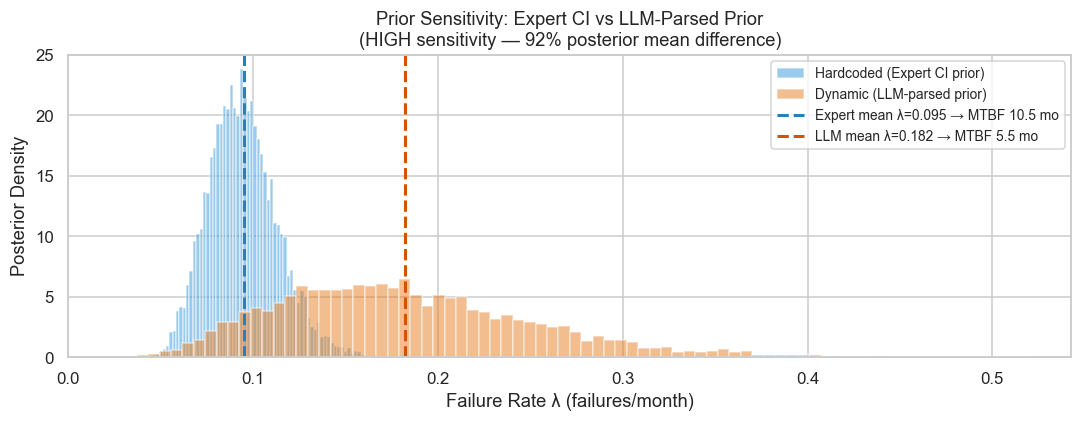

In [165]:
# ── PRIOR SENSITIVITY COMPARISON ──────────────────────────────────────────────
# Compares the hardcoded expert-calibrated posterior against the dynamic
# LLM-seeded posterior to show how much the choice of prior affects the result.

if 'trace' not in globals():
    raise ValueError('Run the Section 7 hardcoded PyMC model cell first.')
if 'trace_dynamic' not in globals():
    raise ValueError('Run the Increment B dynamic builder cell first.')

hc  = az.summary(trace,         var_names=['lambda_rate'], hdi_prob=0.9)
dyn = az.summary(trace_dynamic, var_names=['lambda_rate'], hdi_prob=0.9)

hc_mean  = float(hc.loc['lambda_rate',  'mean'])
dyn_mean = float(dyn.loc['lambda_rate', 'mean'])
hc_lo    = float(hc.loc['lambda_rate',  'hdi_5%'])
hc_hi    = float(hc.loc['lambda_rate',  'hdi_95%'])
dyn_lo   = float(dyn.loc['lambda_rate', 'hdi_5%'])
dyn_hi   = float(dyn.loc['lambda_rate', 'hdi_95%'])
abs_diff = abs(hc_mean - dyn_mean)
pct_diff = abs_diff / hc_mean * 100

display(Markdown('### Prior Sensitivity Analysis Results'))
display(pd.DataFrame({
    'Model':              ['Hardcoded (Expert 90% CI)', 'Dynamic (LLM-parsed JSON)'],
    'Prior source':       ['Path A — calibrated from MTBF CI', f'JSON alpha={alpha_prior:.1f}, beta={beta_prior:.1f}'],
    'Posterior mean λ':   [round(hc_mean, 4),  round(dyn_mean, 4)],
    'Implied MTBF (mo)':  [round(1/hc_mean, 1), round(1/dyn_mean, 1)],
    '90% HDI low':        [round(hc_lo, 4),  round(dyn_lo, 4)],
    '90% HDI high':       [round(hc_hi, 4),  round(dyn_hi, 4)],
}).set_index('Model'))

# ── INTERPRETATION GUIDANCE ────────────────────────────────────────────────────
# Thresholds: <10% = low, 10–30% = moderate, >30% = high sensitivity.
if pct_diff < 10:
    sensitivity = 'LOW'
    interpretation = (
        'Both priors produce similar posteriors. '
        'The observed data dominated the Bayesian update. '
        'The decision recommendation is robust — prior choice does not matter much here.'
    )
elif pct_diff < 30:
    sensitivity = 'MODERATE'
    interpretation = (
        'The two priors produce noticeably different posteriors. '
        'The decision recommendation may shift depending on which prior is used. '
        'AIE action: invest in better prior elicitation (e.g., expert interviews or historical data) '
        'or collect more observations before committing to a strategy.'
    )
else:
    sensitivity = 'HIGH'
    interpretation = (
        'The two priors produce substantially different posteriors and likely different decision recommendations. '
        'Prior choice is the dominant driver of the result — the data alone is insufficient to resolve the uncertainty. '
        'AIE action: this is a high-VoI situation. '
        'Better elicitation, additional measurements, or a pilot study is strongly warranted before deciding.'
    )

print(f'Posterior mean difference: {abs_diff:.4f} failures/month ({pct_diff:.1f}%)')
print(f'Expert prior implied MTBF:  {1/hc_mean:.1f} months')
print(f'LLM prior implied MTBF:     {1/dyn_mean:.1f} months')
print()
display(Markdown(f'**Prior Sensitivity: {sensitivity}**'))
display(Markdown(f'> {interpretation}'))

# ── VISUAL COMPARISON ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(trace.posterior['lambda_rate'].values.flatten(),
        bins=80, density=True, alpha=0.5, color='#3498db',
        label='Hardcoded (Expert CI prior)')
ax.hist(trace_dynamic.posterior['lambda_rate'].values.flatten(),
        bins=80, density=True, alpha=0.5, color='#e67e22',
        label='Dynamic (LLM-parsed prior)')
ax.axvline(hc_mean,  color='#2980b9', lw=2, linestyle='--',
           label=f'Expert mean λ={hc_mean:.3f} → MTBF {1/hc_mean:.1f} mo')
ax.axvline(dyn_mean, color='#d35400', lw=2, linestyle='--',
           label=f'LLM mean λ={dyn_mean:.3f} → MTBF {1/dyn_mean:.1f} mo')
ax.set_xlabel('Failure Rate λ (failures/month)')
ax.set_ylabel('Posterior Density')
ax.set_title(
    f'Prior Sensitivity: Expert CI vs LLM-Parsed Prior\n'
    f'({sensitivity} sensitivity — {pct_diff:.0f}% posterior mean difference)'
)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
lambda_rate,0.0946,0.0188,0.0596,0.129,0.0004,0.0002,2033.2363,3534.6556,1.0007



Analytical posterior mean λ: 0.1806 → MTBF = 5.5 months
MCMC posterior mean λ:       0.0946 → MTBF = 10.6 months
Difference:                  0.08596 (should be ~0 for conjugate model)


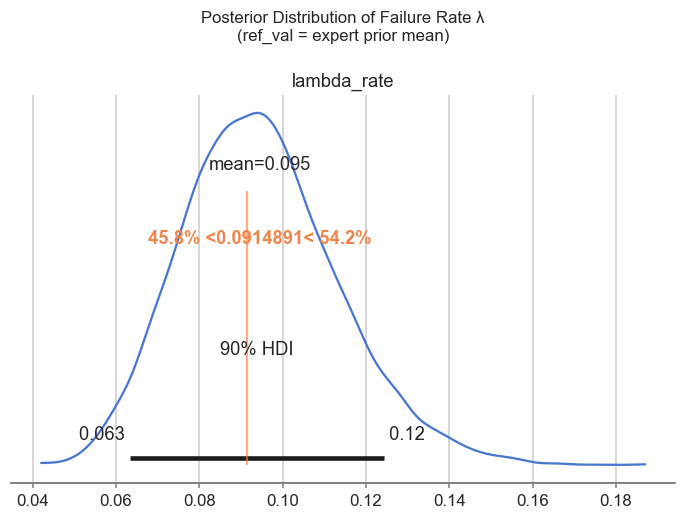

In [171]:
# ── POSTERIOR SUMMARY ─────────────────────────────────────────────────────────
summary = az.summary(trace, var_names=["lambda_rate"], round_to=4)
display(summary)

# Compare analytical vs MCMC posterior
lambda_post_mean_analytical = alpha_post / beta_post
lambda_post_mean_mcmc       = float(trace.posterior["lambda_rate"].mean())

print(f"\nAnalytical posterior mean λ: {lambda_post_mean_analytical:.4f} → MTBF = {1/lambda_post_mean_analytical:.1f} months")
print(f"MCMC posterior mean λ:       {lambda_post_mean_mcmc:.4f} → MTBF = {1/lambda_post_mean_mcmc:.1f} months")
print(f"Difference:                  {abs(lambda_post_mean_analytical - lambda_post_mean_mcmc):.5f} (should be ~0 for conjugate model)")

# Posterior plot
az.plot_posterior(trace, var_names=["lambda_rate"],
                  hdi_prob=0.9,
                  point_estimate="mean",
                  ref_val=mean_expert)
plt.suptitle("Posterior Distribution of Failure Rate λ\n(ref_val = expert prior mean)",
             fontsize=11)
plt.tight_layout()
plt.show()

---
## Section 8 — Step 5b: Chained Bayesian DAG Visualization

The JSON from Section 4 defines a **Directed Acyclic Graph (DAG)** — a chain of dependencies  
from raw measurements → derived quantities → cost outputs.

This visualization shows exactly **where each piece of information enters the model**.

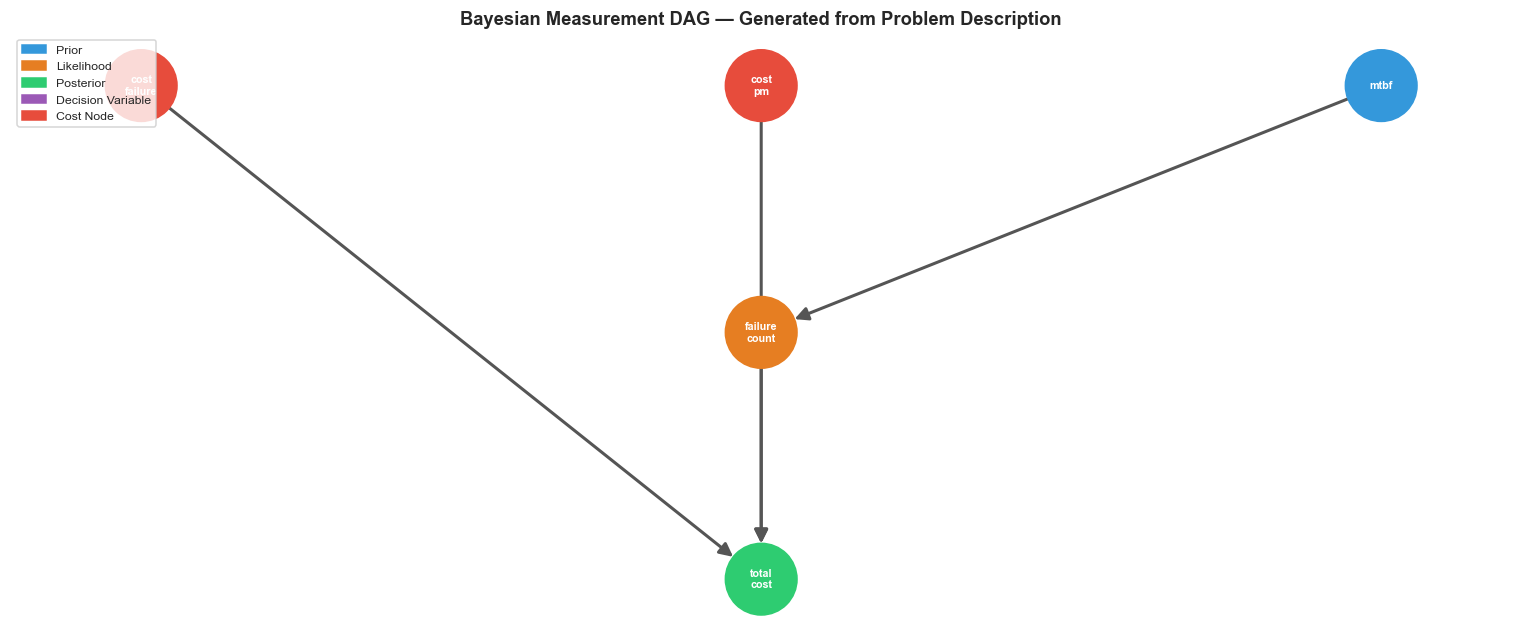

**Bayesian Update Chain:** `mtbf` → `failure_count` → `total_cost`

In [176]:
# ── DAG VISUALIZATION FROM JSON MODEL ─────────────────────────────────────────
# Build NetworkX graph from the LLM-generated JSON

model_json = bayesian_model_json if "bayesian_model_json" in dir() else OFFLINE_JSON

G = nx.DiGraph()

# Color coding by node role
role_colors = {
    "prior":            "#3498db",   # blue
    "likelihood":       "#e67e22",   # orange
    "posterior":        "#2ecc71",   # green
    "decision_variable":"#9b59b6",   # purple
    "cost_node":        "#e74c3c",   # red
}

nodes      = model_json["measurement_nodes"]
node_names = {n["name"] for n in nodes}

for node in nodes:
    G.add_node(node["name"],
               role=node["role"],
               label=node["name"].replace("_", "\n"))

for node in nodes:
    for dep in node.get("depends_on", []):
        if dep in node_names:
            G.add_edge(dep, node["name"])

# Layout: hierarchical top-down by topological generation (pure-Python, no Graphviz needed)
def hierarchical_layout(graph: nx.DiGraph) -> dict:
    """Top-down layered layout based on longest path from any root."""
    depth = {}
    for n in nx.topological_sort(graph):
        preds = list(graph.predecessors(n))
        depth[n] = 0 if not preds else max(depth[p] for p in preds) + 1
    layers: dict[int, list[str]] = {}
    for node, d in depth.items():
        layers.setdefault(d, []).append(node)
    pos = {}
    max_width = max(len(row) for row in layers.values())
    for d, row in layers.items():
        row_sorted = sorted(row)
        for i, node in enumerate(row_sorted):
            x = (i + 1) / (len(row_sorted) + 1) * max_width
            y = -d  # negative so root is on top
            pos[node] = (x, y)
    return pos

try:
    pos = nx.nx_agraph.graphviz_layout(G, prog="dot")
except (ImportError, Exception):
    pos = hierarchical_layout(G)

colors = [role_colors.get(G.nodes[n]["role"], "#95a5a6") for n in G.nodes]
labels = {n: G.nodes[n]["label"] for n in G.nodes}

fig, ax = plt.subplots(figsize=(14, 6))
nx.draw_networkx(
    G, pos=pos, ax=ax,
    labels=labels,
    node_color=colors,
    node_size=2200,
    font_size=7,
    font_color="white",
    font_weight="bold",
    edge_color="#555",
    arrows=True,
    arrowsize=18,
    width=2,
)

# Legend
legend_patches = [mpatches.Patch(color=v, label=k.replace("_", " ").title())
                  for k, v in role_colors.items()]
ax.legend(handles=legend_patches, loc="upper left", fontsize=8)
ax.set_title("Bayesian Measurement DAG — Generated from Problem Description",
             fontsize=12, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.show()

# Print chain
chain = model_json["bayesian_update_chain"]
display(Markdown("**Bayesian Update Chain:** " + " → ".join(f"`{n}`" for n in chain)))

---
## Section 9 — Step 7: Monte Carlo Simulation & Decision Recommendation

Propagate posterior uncertainty through the cost model to produce a **full cost distribution**  
for each strategy, and generate an **auditable decision recommendation**.

In [180]:
# ── MONTE CARLO COST PROPAGATION ───────────────────────────────────────────────
# Draw lambda samples from PyMC posterior trace

lambda_posterior_samples = trace.posterior["lambda_rate"].values.flatten()
N = len(lambda_posterior_samples)
rng2 = np.random.default_rng(seed=99)

# Simulate failure counts under each strategy
k_rtf  = rng2.poisson(lambda_posterior_samples * HORIZON)
k_pm   = rng2.poisson(lambda_posterior_samples * PM_CYCLE * N_PM)

# Total cost
total_cost_rtf = k_rtf * C_FAIL
total_cost_pm  = (N_PM * C_PM) + k_pm * C_FAIL

# Summary statistics
results = pd.DataFrame({
    "Strategy":     ["Run-to-Failure", "6-Month PM"],
    "Mean Cost ($)": [np.mean(total_cost_rtf), np.mean(total_cost_pm)],
    "Median ($)":   [np.median(total_cost_rtf), np.median(total_cost_pm)],
    "P10 ($)":      [np.percentile(total_cost_rtf, 10), np.percentile(total_cost_pm, 10)],
    "P90 ($)":      [np.percentile(total_cost_rtf, 90), np.percentile(total_cost_pm, 90)],
    "P(cheaper) %": [
        np.mean(total_cost_rtf < total_cost_pm) * 100,
        np.mean(total_cost_pm  < total_cost_rtf) * 100
    ]
})
results = results.set_index("Strategy")
dollar_cols = ["Mean Cost ($)", "Median ($)", "P10 ($)", "P90 ($)"]
for col in dollar_cols:
    results[col] = results[col].map(lambda v: f"${v:,.0f}")
results["P(cheaper) %"] = results["P(cheaper) %"].map(lambda v: f"{v:.1f}%")

display(Markdown("### Monte Carlo Cost Summary"))
display(results)

### Monte Carlo Cost Summary

,Mean Cost ($),Median ($),P10 ($),P90 ($),P(cheaper) %
Strategy,,,,,
Run-to-Failure,"$20,608","$18,000",$0,"$54,000",63.8%
6-Month PM,"$24,688","$22,400","$4,400","$58,400",36.2%


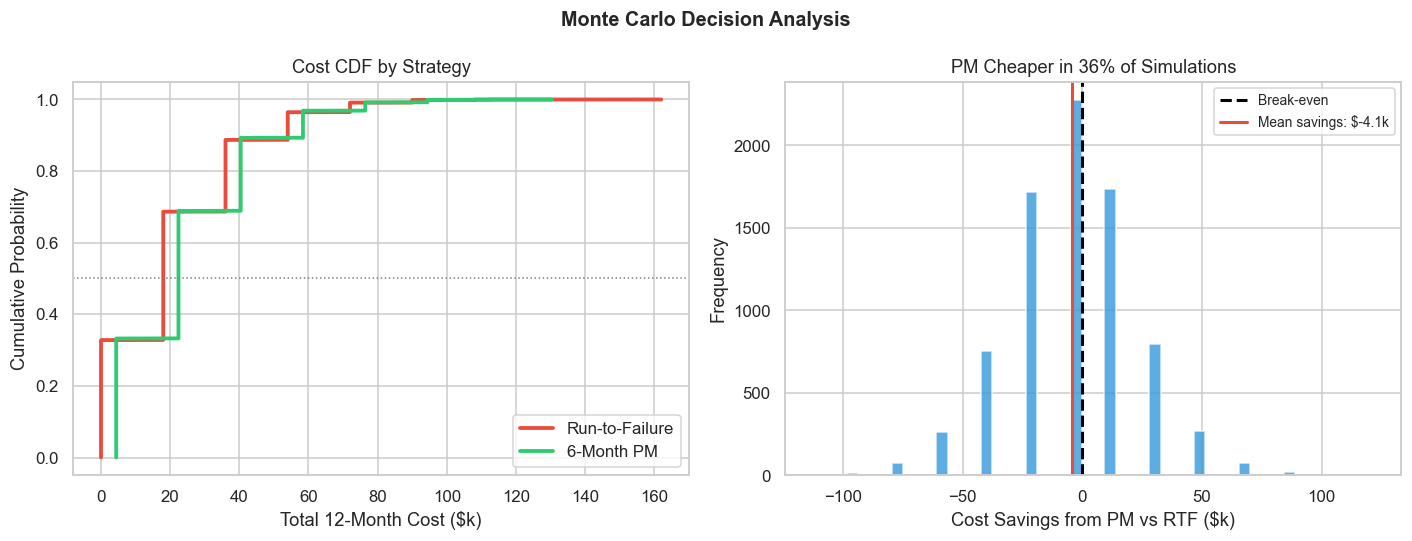


---
### Decision Recommendation

**Recommended Strategy**: **Run-to-Failure**

- PM is the lower-cost strategy in **36%** of simulated scenarios.
- Expected savings from PM over 12 months: **$-4,080**
- EVPI = **$-55** — additional investment in failure-rate characterization  
  (e.g., vibration monitoring) is not required.

*This recommendation is based on 8,000 posterior draws and 8,000 Monte Carlo simulations.*


In [183]:
# ── DECISION VISUALIZATION ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Cost CDFs
for cost, label, color in [
    (total_cost_rtf, "Run-to-Failure", "#e74c3c"),
    (total_cost_pm,  "6-Month PM",     "#2ecc71")
]:
    sorted_cost = np.sort(cost)
    cdf = np.arange(1, len(sorted_cost)+1) / len(sorted_cost)
    axes[0].plot(sorted_cost/1000, cdf, lw=2.5, label=label, color=color)

axes[0].set_xlabel("Total 12-Month Cost ($k)")
axes[0].set_ylabel("Cumulative Probability")
axes[0].set_title("Cost CDF by Strategy")
axes[0].axhline(0.5, color="gray", linestyle=":", lw=1)
axes[0].legend()

# Savings distribution
savings = total_cost_rtf - total_cost_pm
axes[1].hist(savings/1000, bins=50, color="#3498db", edgecolor="white", alpha=0.8)
axes[1].axvline(0, color="black", lw=2, linestyle="--", label="Break-even")
axes[1].axvline(np.mean(savings)/1000, color="#e74c3c", lw=2,
                label=f"Mean savings: ${np.mean(savings)/1000:.1f}k")
pct_pm_wins = np.mean(savings > 0) * 100
axes[1].set_xlabel("Cost Savings from PM vs RTF ($k)")
axes[1].set_ylabel("Frequency")
axes[1].set_title(f"PM Cheaper in {pct_pm_wins:.0f}% of Simulations")
axes[1].legend(fontsize=9)

plt.suptitle("Monte Carlo Decision Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# ── RECOMMENDATION ────────────────────────────────────────────────────────────
mean_savings = np.mean(savings)
rec = "6-Month Preventive Maintenance" if mean_savings > 0 else "Run-to-Failure"
display(Markdown(f"""
---
### Decision Recommendation

**Recommended Strategy**: **{rec}**

- PM is the lower-cost strategy in **{pct_pm_wins:.0f}%** of simulated scenarios.
- Expected savings from PM over 12 months: **${mean_savings:,.0f}**
- EVPI = **${EVPI:,.0f}** — additional investment in failure-rate characterization  
  (e.g., vibration monitoring) is {'justified' if EVPI > 500 else 'not required'}.

*This recommendation is based on {N:,} posterior draws and {N:,} Monte Carlo simulations.*
"""))

---
## Section 10 — Your Turn: Participant Exercise

Replace the decision frame below with **your own reliability problem**.  
The LLM will map it into a Bayesian structure automatically.

**Suggested exercise scenarios:**
1. A conveyor belt system with 5 failures over 18 months — decide on predictive vs. scheduled maintenance.
2. A safety valve with no failures in 36 months — is the current inspection interval adequate?
3. A fleet of 12 motors with mixed failure history — prioritize which unit to maintain first.

---
### ## YOUR TURN — Edit the cell below

In [184]:
# ── PARTICIPANT EXERCISE ───────────────────────────────────────────────────────
# Replace the values below with your own problem.
# Then re-run ALL cells from Section 3 onward.

my_decision_frame = {
    "problem_description": """
        << DESCRIBE YOUR RELIABILITY PROBLEM HERE >>
        Include: asset type, failure history, costs, time horizon, and decision options.
    """,
    "decision_options": [
        "Option A",
        "Option B"
    ],
    "objective": "Minimize expected cost over the planning horizon",
    "time_horizon_months": 12,
    "cost_pm_per_intervention_usd": 0,     # Replace with your PM cost
    "cost_unplanned_failure_usd": 0,       # Replace with your failure cost
    "observed_failures": 0,                # Replace with observed failure count
    "observation_period_months": 12,       # Replace with observation duration
    "industry_mtbf_range_months": [6, 18], # Replace with your 90% CI on MTBF
}

# Uncomment to use your frame and re-run from Section 3:
# decision_frame = my_decision_frame
# bayesian_model_json = parse_problem_to_json(my_decision_frame["problem_description"])
# print(json.dumps(bayesian_model_json, indent=2))

print("Exercise template ready. Fill in the fields above and uncomment the last lines.")

Exercise template ready. Fill in the fields above and uncomment the last lines.


---
## References

1. **Hubbard, D.** (2014). *How to Measure Anything: Finding the Value of Intangibles in Business* (3rd ed.). Wiley.
2. **Hubbard, D.** (2025). *How to Measure Anything in AI: Quantitative Techniques for Decision-Making*. LinkedIn Learning.
3. **LLM-BI**: *Towards Fully Automated Bayesian Inference with Large Language Models*. arXiv:2508.08300 (Aug 2025).
4. **Lorenz & Fritz** (2026). *Scalable Delphi: LLM-Assisted Expert Elicitation for Calibrated Priors*. arXiv (Feb 2026).
5. **Salvatier, J., Wiecki, T., Fonnesbeck, C.** (2016). Probabilistic programming in Python using PyMC3. *PeerJ Computer Science*.
6. **Kumar & Klefsjö** (1994). Proportional hazards model: a review. *Reliability Engineering & System Safety*, 44(2), 177-188.

---
*Notebook version 1.0 — RAMS 2027 Tutorial Submission*  
*Author: Kirtis Christensen | Bayesian Mentor: Grok (xAI)*  
*Generated: April 30, 2026*